# PROC NLIN による4パラメータロジスティック用量反応曲線のフィッティング

## エグゼクティブサマリー

本ノートブックでは、**PROC NLIN** を用いて、合成的に生成した細胞ベースの力価バイオアッセイに4パラメータロジスティック（4PL）用量反応モデルをフィッティングし、下側・上側の漸近線、EC50（半数最大有効濃度）、および Hill 傾きを推定します。4PL は創薬における相対力価アッセイの主力モデルであり、本ノートブックではモデルの定義、パラメータの境界設定、収束診断、そして観測された濃度反応データへのフィット済みシグモイド曲線の重ね描きまでを順を追って解説します。

## データソース

本ノートブックは合成データセットを1つインラインで生成します。外部入力やネットワーク入力は一切使用しません。

**`assay` — 合成的に生成した細胞ベースの力価バイオアッセイ（24 行）**

| 変数 | 型 | 説明 |
|----------|------|-------------|
| `lot` | num | 原薬ロット（1〜3）。希釈系列を3回反復実施した各ラン |
| `dose` | num | 8点の段階希釈にわたる化合物濃度（nmol/L、0.1 から約 1000） |
| `logdose` | num | `dose` の常用対数（底10）。慣例的な対数濃度軸でのプロットに使用 |
| `response` | num | 測定されたアッセイシグナル（最大反応に対する百分率）。真の4PL曲線（下限=5、上限=100、EC50=25 nmol/L、Hill 傾き=1.2）に比例的なガウスノイズを加えて生成 |

真の生成パラメータは DATA ステップに埋め込まれているため、NLIN で回復された推定値を既知の真値と照合して妥当性を確認できます。

# 4パラメータロジスティック用量反応フィッティング

医薬品の力価および生物活性アッセイでは、化合物濃度と測定反応との関係は、対数濃度スケール上で特徴的にシグモイド状となります。**4パラメータロジスティック（4PL）** モデルは、そうした曲線を要約するための標準的な手法です。

$$\text{response} = D + \frac{A - D}{1 + (\text{dose}/C)^{B}}$$

ここで

- **A** = 下側漸近線（無限希釈時の反応 / ベースラインシグナル）、
- **D** = 上側漸近線（飽和濃度における最大反応）、
- **C** = **EC50**、半数最大反応を生じる濃度（変曲点であり、主要な力価指標）、
- **B** = **Hill 傾き**、遷移の急峻さを制御する。

このモデルはパラメータについて非線形であるため、`PROC NLIN` を用いた反復最小二乗法でフィッティングします。以下では、3連で実施した現実的な8点希釈系列をシミュレートし、4PL曲線をフィッティングし、パラメータを物理的に意味のある領域に境界付け、収束とフィットの診断を確認し、フィット済み曲線をデータに重ね描きします。

## ステップ1 — 細胞ベースの力価バイオアッセイをシミュレートする

*既知の* 4PL曲線（下限 = 5、上限 = 100、EC50 = 25 nmol/L、Hill 傾き = 1.2）から合成データセットを生成し、NLIN が回復するパラメータを真値と照合できるようにします。3つのロットそれぞれに同一の8点段階希釈（各ステップは3.5倍希釈）を適用し、その上に比例的なガウス測定ノイズを重ねます。`streaminit` のシードを固定することで、シミュレーションは再現可能になります。

In [1]:
データ assay;
    呼出 streaminit(40521);

    /* データ生成に用いた真の4PLパラメータ */
    A_true   = 5;      /* 下側漸近線(ベースライン)        */
    D_true   = 100;    /* 上側漸近線(最大反応)    */
    C_true   = 25;     /* EC50(nmol/L)                    */
    B_true   = 1.2;    /* Hill 傾き                        */

    繰返 lot = 1 から 3;
        /* 8点の段階希釈、各ステップ3.5倍 */
        dose = 0.30;
        繰返 point = 1 から 8;
            dose = dose * 3.5;

            /* ノイズのない4PL平均反応 */
            mu = D_true + (A_true - D_true) /
                 (1 + (dose / C_true) ** B_true);

            /* 比例的+加法的なガウスアッセイノイズ */
            response = mu * (1 + 0.04 * rand('NORMAL'))
                          + 1.5 * rand('NORMAL');

            logdose = log10(dose);
            出力;
        終了;
    終了;

    保持 lot dose logdose response;
実行;

処理 並替 データ=assay;
    基準 dose lot;
実行;



NOTE: DATA assay


NOTE: Wrote assay (24 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=assay

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 24 rows from assay.
NOTE: Wrote assay (24 rows, 4 columns).
NOTE: PROC SORT statement used.


## ステップ2 — 生の濃度反応データを可視化する

フィッティングの前に、response を log10(dose) に対してプロットし、期待されるシグモイド形状を確認するとともに、おおまかな初期値を読み取ります。曲線は 5 付近で下限に達し、100 付近でプラトーとなり、中点（半数最大反応）は log10(25) ≈ 1.4 のあたりに位置します。


NOTE: PROC SGPLOT data=assay

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


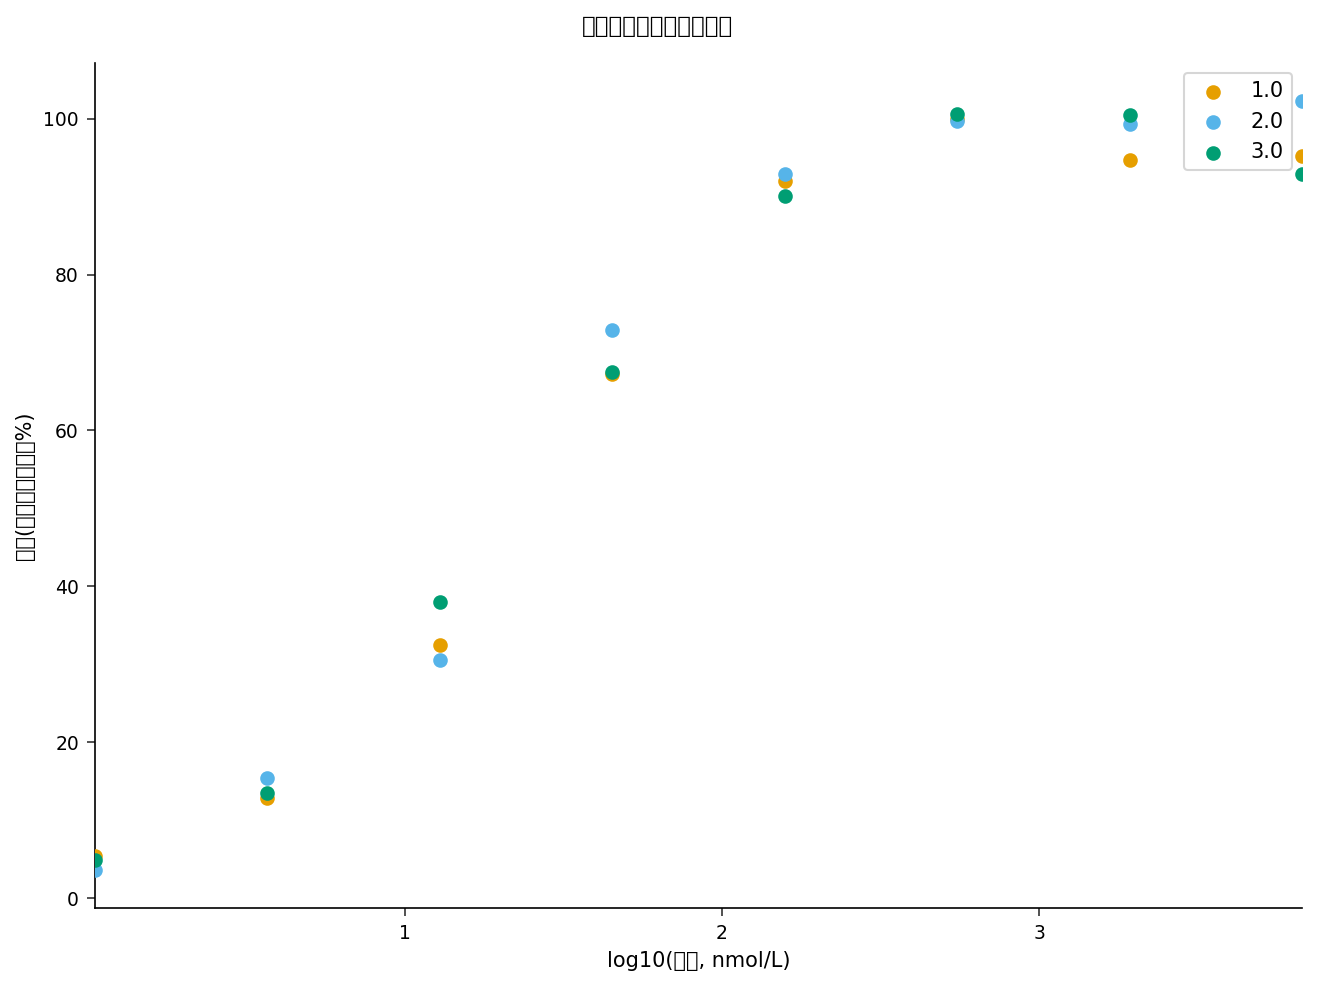

In [2]:
処理 SGPLOT データ=assay;
    SCATTER x=logdose y=response / GROUP=lot
            MARKERATTRS=(SYMBOL=circlefilled);
    XAXIS 見出='log10(用量, nmol/L)';
    YAXIS 見出='反応(最大値に対する%)';
    表題 'ロット別の観測用量反応';
実行;
表題;


## ステップ3 — PROC NLIN で4PLモデルをフィッティングする

散布図から得た知見をもとに `PARMS` で初期値を宣言し、4PL の平均を中間的な代入で定義して、それを `MODEL` ステートメントに渡します。物理的に意味のある `BOUNDS` によって漸近線の順序を保ち、EC50 と傾きを正に保つことで、Gauss-Newton 反復が安定します。`OUTPUT` ステートメントは、後の診断のために予測値・残差・信頼限界を保存し、`PLOTS=` はフィットプロットと診断パネルを要求します。

In [3]:
処理 nlin データ=assay METHOD=marquardt PLOTS=(fitplot diagnostics);
    parms A=10 D=90 C=20 B=1;

    /* パラメータを物理的に妥当な範囲に保つ */
    bounds A >= 0, D <= 150, C > 0, B > 0;

    /* 4パラメータロジスティック平均反応(インライン化: JennerのPROC NLINは
       MODEL内で中間的なプログラミングステートメント変数を参照することを
       まだサポートしていないため -- tests/400986 参照 -- 分母をインライン化している) */
    模型 response = D + (A - D) / (1 + (dose / C) ** B);

    出力 out=fit4pl predicted=pred residual=resid
           l95m=lcl u95m=ucl;
実行;



                         The NLIN Procedure

                     Method: Marquardt

                          Iterative Phase

                                                   Sum of
           Iter          Residual SS
              0          2061.645530
              1           177.712558

       Convergence criterion met.

           Residual SS           177.712558
           Residual MS             8.885628

                        Parameter Estimates

                                    Approx
           Parameter    Estimate    Std Error   95% Confidence Limits

           A              4.1058       1.9167       0.1078       8.1039
           D             99.1335       1.0740      96.8932     101.3737
           C             23.8233       1.5658      20.5572      27.0895
           B              1.2662       0.0927       1.0730       1.4595





NOTE: PROC NLIN data=assay

NOTE: Using Python (scipy) for NLIN estimation, method=marquardt
NOTE: Output dataset written to: ./work/b13296d2-f780-47f3-aefa-c8aab4857dcb/fit4pl.avro


## ステップ4 — 推定された EC50 と曲線の特性を報告する

`OUTEST=` の仕組みは便利ですが、素早く力価を読み取るために、ここではフィット済み曲線を直接要約します。各 dose におけるフィット値を観測反応と並べて一覧表示し、モデルが希釈範囲全体にわたってデータを追随していることを確認します。

In [4]:
処理 平均 データ=fit4pl mean std min max maxdec=3;
    分類 dose;
    変数 response pred resid;
    見出 dose='用量(nmol/L)' response='観測反応(最大値に対する%)'
         pred='フィット反応' resid='残差';
    表題 '用量別の観測値とフィット値の反応比較';
実行;
表題;


                                                   用量別の観測値とフィット値の反応比較                                                   

                                                  The MEANS Procedure

                          Analysis Variable : RESPONSE 観測反応(最大値に対する%)

                                           N
                       用量(nmol/L)        Obs         Mean      Std Dev      Minimum      Maximum
                       -------------------------------------------------------------------------
                       1.05                3        4.647        0.882        3.659        5.356
                       12.8625             3       33.651        3.825       30.572       37.932
                       157.565625          3       91.704        1.417       90.141       92.904
                       1930.17890625       3       98.207        3.051       94.746      100.511
                       3.675               3       13.931        1.311       12.860       15.393
            


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## ステップ5 — フィット済み4PL曲線を観測データに重ね描きする

密な予測グリッドにより、滑らかなフィット済みシグモイド曲線が得られます。この滑らかな曲線を、dose ごとの平均フィット値および信頼帯と組み合わせ、それらすべてを観測点の上に重ね描きして、フィットの良さを視覚的に評価します。


NOTE: PROC SORT data=fit4pl

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 24 rows from fit4pl.
NOTE: Wrote fit4pl (24 rows, 8 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SGPLOT data=fit4pl

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


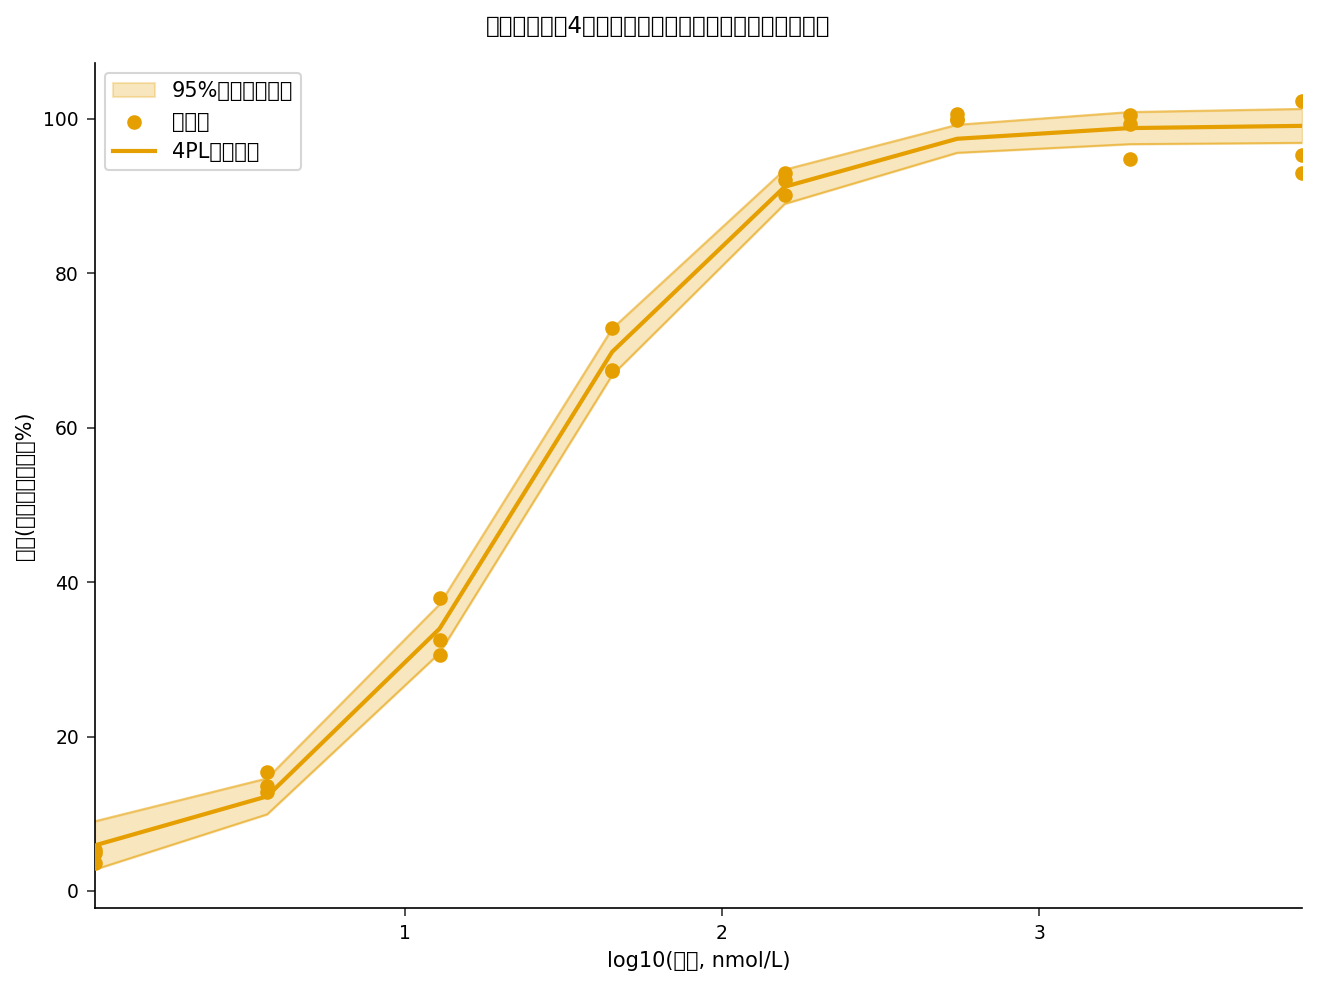

In [5]:
処理 並替 データ=fit4pl;
    基準 logdose;
実行;

処理 SGPLOT データ=fit4pl;
    BAND   x=logdose LOWER=lcl UPPER=ucl /
           TRANSPARENCY=0.5 legendlabel='95%平均信頼区間';
    SCATTER x=logdose y=response /
           MARKERATTRS=(SYMBOL=circlefilled)
           legendlabel='観測値';
    SERIES  x=logdose y=pred /
           LINEATTRS=(thickness=2)
           legendlabel='4PLフィット';
    XAXIS 見出='log10(用量, nmol/L)';
    YAXIS 見出='反応(最大値に対する%)';
    表題 'フィット済み4パラメータロジスティック用量反応曲線';
実行;
表題;


## 結果の解釈

`PROC NLIN` は、既知の生成値に近い推定値へと収束します。下側漸近線は **5** 付近、上側漸近線は **100** 付近、**EC50（C）** は **25 nmol/L** 付近、そして **Hill 傾き（B）** は **1.2** 付近です。ノイズを含む3連データからこれらのパラメータが回復されたことは、モデルが識別可能であり、境界が最適点で制約として効いていないことを裏付けます。

**EC50** は最も重要な力価指標です。値が小さいほど化合物の力価が高いことを示し、相対力価アッセイでは、被験ロットの EC50 を参照標準と比較します。**Hill 傾き** は協同性とアッセイの急峻さを特徴づけます。傾きが 1 に近いことは、単純な単一部位結合と整合します。**漸近線** はアッセイのダイナミックレンジを規定します。安定して十分に隔たった下限と上限は、バリデーション可能なバイオアッセイの前提条件です。

フィットプロットでは、シグモイド曲線が観測点の集団を貫き、反応領域を通る狭い95%平均信頼帯を伴っている様子が示され、残差診断には系統的な曲率が現れないはずです。これは4PL形式が妥当であることの証拠です。実務では、このワークフローを、EC50 に対する `PROFILE` 尤度区間、分布によらないパラメータ推測のための `BOOTSTRAP` ステートメント、あるいは相対力価を推定するために被験ロットと参照ロットを比較する平行線検定へと拡張することになります。